### connectin n importin

In [5]:
import pandas as pd
import sqlite3
import seaborn as sns
import matplotlib.pyplot as plt

In [12]:
db_path = "/Users/abdul/OneDrive/Desktop/dev/invoiceML/data/inventory.db"
conn = sqlite3.connect(db_path)
tables = pd.read_sql_query("SELECT name FROM sqlite_master WHERE type='table';", conn)
tables

,name
0,purchases
1,purchase_prices
2,vendor_invoice
3,begin_inventory
4,end_inventory


### explorin

In [18]:
for table in tables['name']:
    print(f"Table: {table}")
    df = pd.read_sql_query(f"SELECT * FROM {table} limit 2", conn)
    display(df)

Table: purchases


,InventoryId,Store,Brand,Description,Size,VendorNumber,VendorName,PONumber,PODate,ReceivingDate,InvoiceDate,PayDate,PurchasePrice,Quantity,Dollars,Classification
0,69_MOUNTMEND_8412,69,8412,Tequila Ocho Plata Fresno,750mL,105,ALTAMAR BRANDS LLC,8124,2023-12-21,2024-01-02,2024-01-04,2024-02-16,35.71,6,214.26,1
1,30_CULCHETH_5255,30,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,4,37.40,1


Table: purchase_prices


,Brand,Description,Price,Size,Volume,Classification,PurchasePrice,VendorNumber,VendorName
0,58,Gekkeikan Black & Gold Sake,12.99,750mL,750,1,9.28,8320,SHAW ROSS INT L IMP LTD
1,62,Herradura Silver Tequila,36.99,750mL,750,1,28.67,1128,BROWN-FORMAN CORP


Table: vendor_invoice


,VendorNumber,VendorName,InvoiceDate,PONumber,PODate,PayDate,Quantity,Dollars,Freight,Approval
0,105,ALTAMAR BRANDS LLC,2024-01-04,8124,2023-12-21,2024-02-16,6,214.26,3.47,None
1,4466,AMERICAN VINTAGE BEVERAGE,2024-01-07,8137,2023-12-22,2024-02-21,15,140.55,8.57,None


Table: begin_inventory


,InventoryId,Store,City,Brand,Description,Size,onHand,Price,startDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,8,12.99,2024-01-01
1,1_HARDERSFIELD_60,1,HARDERSFIELD,60,Canadian Club 1858 VAP,750mL,7,10.99,2024-01-01


Table: end_inventory


,InventoryId,Store,City,Brand,Description,Size,onHand,Price,endDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,11,12.99,2024-12-31
1,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,7,36.99,2024-12-31


In [19]:
ven_invoices = pd.read_sql_query("SELECT * FROM vendor_invoice", conn)
ven_invoices.head()

,VendorNumber,VendorName,InvoiceDate,PONumber,PODate,PayDate,Quantity,Dollars,Freight,Approval
0,105,ALTAMAR BRANDS LLC,2024-01-04,8124,2023-12-21,2024-02-16,6,214.26,3.47,NaN
1,4466,AMERICAN VINTAGE BEVERAGE,2024-01-07,8137,2023-12-22,2024-02-21,15,140.55,8.57,NaN
2,388,ATLANTIC IMPORTING COMPANY,2024-01-09,8169,2023-12-24,2024-02-16,5,106.60,4.61,NaN
3,480,BACARDI USA INC,2024-01-12,8106,2023-12-20,2024-02-05,10100,137483.78,2935.20,NaN
4,516,BANFI PRODUCTS CORP,2024-01-07,8170,2023-12-24,2024-02-12,1935,15527.25,429.20,NaN


### relation bw quantity freight and dollars (linear)

In [20]:
ven_invoices[['Quantity', 'Freight', 'Dollars']].corr()

,Quantity,Freight,Dollars
Quantity,1.000000,0.946550,0.963831
Freight,0.946550,1.000000,0.985141
Dollars,0.963831,0.985141,1.000000


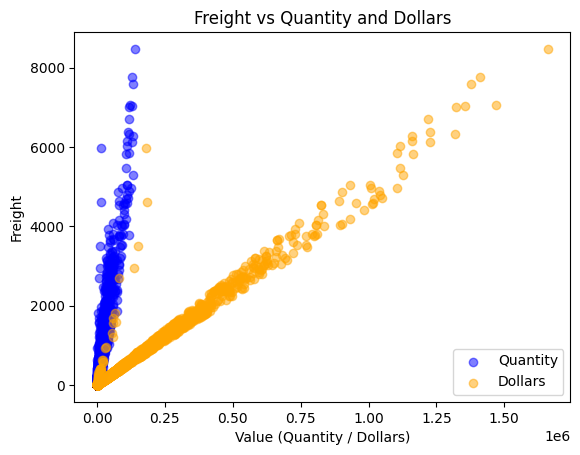

In [23]:
# 1. Plot Quantity vs Freight (Blue)
plt.scatter(ven_invoices['Quantity'], ven_invoices['Freight'], 
            color='blue', label='Quantity', alpha=0.5)

# 2. Plot Dollars vs Freight (Orange) on the same graph
plt.scatter(ven_invoices['Dollars'], ven_invoices['Freight'], 
            color='orange', label='Dollars', alpha=0.5)

# 3. Add details
plt.ylabel('Freight')
plt.xlabel('Value (Quantity / Dollars)')
plt.title('Freight vs Quantity and Dollars')
plt.legend() # This shows the color key

plt.show()

### bulk order means low freight

In [24]:
ven_invoices['freight_per_unit'] = ven_invoices['Freight'] / ven_invoices['Quantity']
low_quantity = ven_invoices['Quantity'].quantile(0.25)
high_quantity = ven_invoices['Quantity'].quantile(0.75)
print(low_quantity)
print(high_quantity)

83.0
5100.5


In [26]:
ven_invoices.loc[ven_invoices['Quantity'] < low_quantity, 'freight_per_unit'].mean()

np.float64(0.09489854253138316)

In [25]:
ven_invoices.loc[ven_invoices['Quantity'] > high_quantity, 'freight_per_unit'].mean()

np.float64(0.049077654690759046)

### model (linear reg 4 da win)

In [89]:
X = ven_invoices[['Dollars']]
y = ven_invoices['Freight']

In [90]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [91]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

In [92]:
model1 = LinearRegression()
model1.fit(X_train, y_train)

model2 = DecisionTreeRegressor(max_depth=4, random_state=42)
model2.fit(X_train, y_train)

model3 = RandomForestRegressor(max_depth=6, random_state=42)
model3.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",6
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples a

In [ ]:
def evaluate_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = root_mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)*100
    print(f"Model: {model_name}")
    print(f"MAE: {mae:.2f}, RMSE: {rmse:.2f}, R²: {r2:.2f}")
    return mae

In [94]:
evaluate_model(model1, X_test, y_test, "Linear Regression")
evaluate_model(model2, X_test, y_test, "Decision Tree Regressor")
evaluate_model(model3, X_test, y_test, "Random Forest Regressor")

Model: Linear Regression
MAE: 24.11, RMSE: 124.72, R²: 96.99
Model: Decision Tree Regressor
MAE: 38.12, RMSE: 138.25, R²: 96.30
Model: Random Forest Regressor
MAE: 26.13, RMSE: 134.79, R²: 96.48


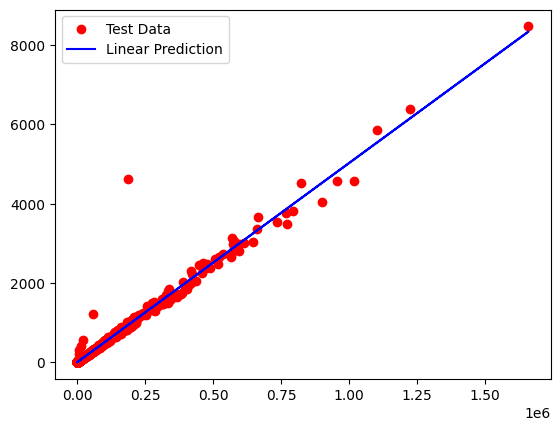

In [96]:
import matplotlib.pyplot as plt

# 1. Get predictions from your Linear Regression model
y_pred_linear = model1.predict(X_test)

# 2. Plotting (Exactly like the tutorial)
plt.scatter(X_test, y_test, color='red', label='Test Data')
plt.plot(X_test, y_pred_linear, color='blue', label='Linear Prediction')

plt.legend()
plt.show()

In [98]:
# inferencing
input = {
    "Dollars": [500, 1200]
}
input_df = pd.DataFrame(input)
model1.predict(input_df)

array([ 7.51560602, 11.02622562])